# Домашнее задание - линейная регрессия

### Работа с признаками (8 баллов)

Скачайте датасет из материалов к уроку или по ссылке https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv


Описание признаков:

* Agency — название страхового агентства
* Agency Type — тип страхового агентства
* Distribution Channel — канал продвижения страхового агентства
* Product Name — название страхового продукта
* Duration — длительность поездки (количество дней)
* Destination — направление поездки
* Net Sales — сумма продаж
* Commission (in value) — комиссия страхового агентства
* Gender — пол застрахованного
* Age — возраст застрахованного

Ответ:
* Claim — потребовалась ли страховая выплата: «да» — 1, «нет» — 0

Обработайте пропущенные значения и примените написанные функции onehot_encode() и minmax_scale().

**Подсказка**: маску для категориальных признаков можно сделать фильтром cat_features_mask = (df.dtypes == "object").values

In [ ]:
import pandas as pd
import numpy as np

url='https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv'
df=pd.read_csv(url)
df

,Agency,Agency Type,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Gender,Age
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,81
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,71
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,65,AUSTRALIA,-49.5,29.70,NaN,32
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,60,AUSTRALIA,-39.6,23.76,NaN,32
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,79,ITALY,-19.8,11.88,NaN,41
...,...,...,...,...,...,...,...,...,...,...,...
63321,JZI,Airlines,Online,Basic Plan,No,111,JAPAN,35.0,12.25,M,31
63322,JZI,Airlines,Online,Basic Plan,No,58,CHINA,40.0,14.00,F,40
63323,JZI,Airlines,Online,Basic Plan,No,2,MALAYSIA,18.0,6.30,M,57
63324,JZI,Airlines,Online,Basic Plan,No,3,VIET NAM,18.0,6.30,M,63


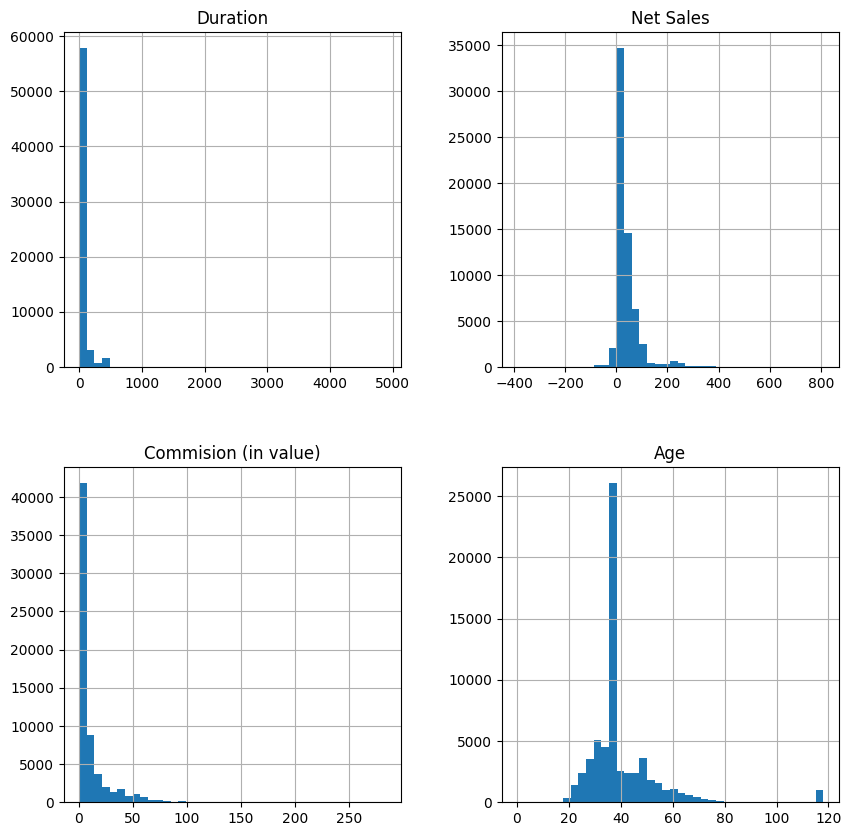

In [ ]:
datanum = df.select_dtypes(include = ['float64', 'int64'])
datanum.hist(figsize=(10, 10), bins=40);

In [ ]:
df['Claim'].value_counts()#дисбаланс!!!

,count
Claim,
No,62399
Yes,927


In [ ]:
df.info()# нет пропусков кроме пола

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63326 entries, 0 to 63325
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                63326 non-null  object 
 1   Agency Type           63326 non-null  object 
 2   Distribution Channel  63326 non-null  object 
 3   Product Name          63326 non-null  object 
 4   Claim                 63326 non-null  object 
 5   Duration              63326 non-null  int64  
 6   Destination           63326 non-null  object 
 7   Net Sales             63326 non-null  float64
 8   Commision (in value)  63326 non-null  float64
 9   Gender                18219 non-null  object 
 10  Age                   63326 non-null  int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 5.3+ MB


In [ ]:
df['Gender'].isna().sum()/df.shape[0]
#тут аж 70% пропусков не уверена что заполнить пропуски- корректная стратегия. я бы дропнула лучше

0.7122982661150239

In [ ]:
df['Distribution Channel'].value_counts()#тут тоже можно дропнуть явный дисбаланс ничего не получится извлечь

,count
Distribution Channel,
Online,62219
Offline,1107


In [ ]:
df=df.drop(['Distribution Channel','Gender'],axis=1)

In [ ]:
df['Claim']=np.where(df['Claim'] == 'Yes', 1,0)

In [ ]:
import numpy as np

def onehot_encoding(x):
    num = sorted(np.unique(x))
    matrix = np.zeros((len(x), len(num)), dtype = int)
    for i in range(len(x)):
      index = num.index(x[i])
      if index > 0:  # Пропускаем первый элемент чтобы избежать мултиколлинеарности
        matrix[i][index - 1] = 1
    return matrix

def minmax_scale(X):
    X = X.astype(float)
    for i in range(X.shape[1]):
        X_column_max = X.iloc[:, i].max()
        X_column_min = X.iloc[:, i].min()
        if X_column_max == X_column_min:
            X.iloc[:, i] = 0
        else:
            X.iloc[:, i] = (X.iloc[:, i] - X_column_min) / (X_column_max - X_column_min)
    return X

In [ ]:
cat_features_mask = (df.dtypes == "object").values
category = df.loc[:, cat_features_mask]
onehot_colum=[onehot_encoding(category[col]) for col in category.columns]#кодирую
onehot_matrix=np.hstack(onehot_colum)# по сути они уже отмасштабированы тк там только 0 и 1

In [ ]:
number = df.loc[:, np.logical_not(cat_features_mask)]
number_scale=minmax_scale(number)#масштабирую

final_matrix=np.hstack([number_scale,onehot_matrix])

In [ ]:
name=category.columns.to_list()
for i in name:
  print(category[i].unique())# просто проверка на уникальные значениям по каждому столбцу

['CBH' 'CWT' 'JZI' 'KML' 'EPX' 'C2B' 'JWT' 'RAB' 'SSI' 'ART' 'CSR' 'CCR'
 'ADM' 'LWC' 'TTW' 'TST']
['Travel Agency' 'Airlines']
['Comprehensive Plan' 'Rental Vehicle Excess Insurance' 'Value Plan'
 'Basic Plan' 'Premier Plan' '2 way Comprehensive Plan' 'Bronze Plan'
 'Silver Plan' 'Annual Silver Plan' 'Cancellation Plan'
 '1 way Comprehensive Plan' 'Ticket Protector' '24 Protect' 'Gold Plan'
 'Annual Gold Plan' 'Single Trip Travel Protect Silver'
 'Individual Comprehensive Plan' 'Spouse or Parents Comprehensive Plan'
 'Annual Travel Protect Silver' 'Single Trip Travel Protect Platinum'
 'Annual Travel Protect Gold' 'Single Trip Travel Protect Gold'
 'Annual Travel Protect Platinum' 'Child Comprehensive Plan'
 'Travel Cruise Protect' 'Travel Cruise Protect Family']
['MALAYSIA' 'AUSTRALIA' 'ITALY' 'UNITED STATES' 'THAILAND'
 "KOREA, DEMOCRATIC PEOPLE'S REPUBLIC OF" 'NORWAY' 'VIET NAM' 'DENMARK'
 'SINGAPORE' 'JAPAN' 'UNITED KINGDOM' 'INDONESIA' 'INDIA' 'CHINA' 'FRANCE'
 'TAIWAN, PROVINCE 

In [ ]:
pd.set_option("display.max_rows", 1000)# что бы все можно было увидеть
category['Destination'].value_counts()#ну тут логично сгруппировать по частям света

,count
Destination,
SINGAPORE,13255
MALAYSIA,5930
THAILAND,5894
CHINA,4796
AUSTRALIA,3694
INDONESIA,3452
UNITED STATES,2530
PHILIPPINES,2490
HONG KONG,2411


Подробный анализ и подготовка датасета часто помогают улучшить качество модели. Ниже представлено несколько идей преобразований. Вы можете применить одно или несколько из этих преобразований (а можете не применять), чтобы помочь будущей модели.

1. Посмотрите на количественные признаки. Возможно, в некоторых признаках есть выбросы - значения, которые сильно выбиваются. Такие значения полезно удалять. Советуем присмотреться к колонке Duration)

2. Можно заметить, что one hot encoding сильно раздувает количество столбцов. Радикальное решение - можно попробовать выбросить все категориальные признаки из датасета.

3. Если все-таки оставляете категориальные признаки, то подумайте, как уменьшить количество столбцов после one hot encoding. Признаки с большим количеством значений (Duration - 149! разных стран) можно удалить или попробовать сгруппировать некоторые значения.

4. Downsampling. Датасет достаточно большой, разница в классах огромная. Можно уменьшить число наблюдений с частым ответом.

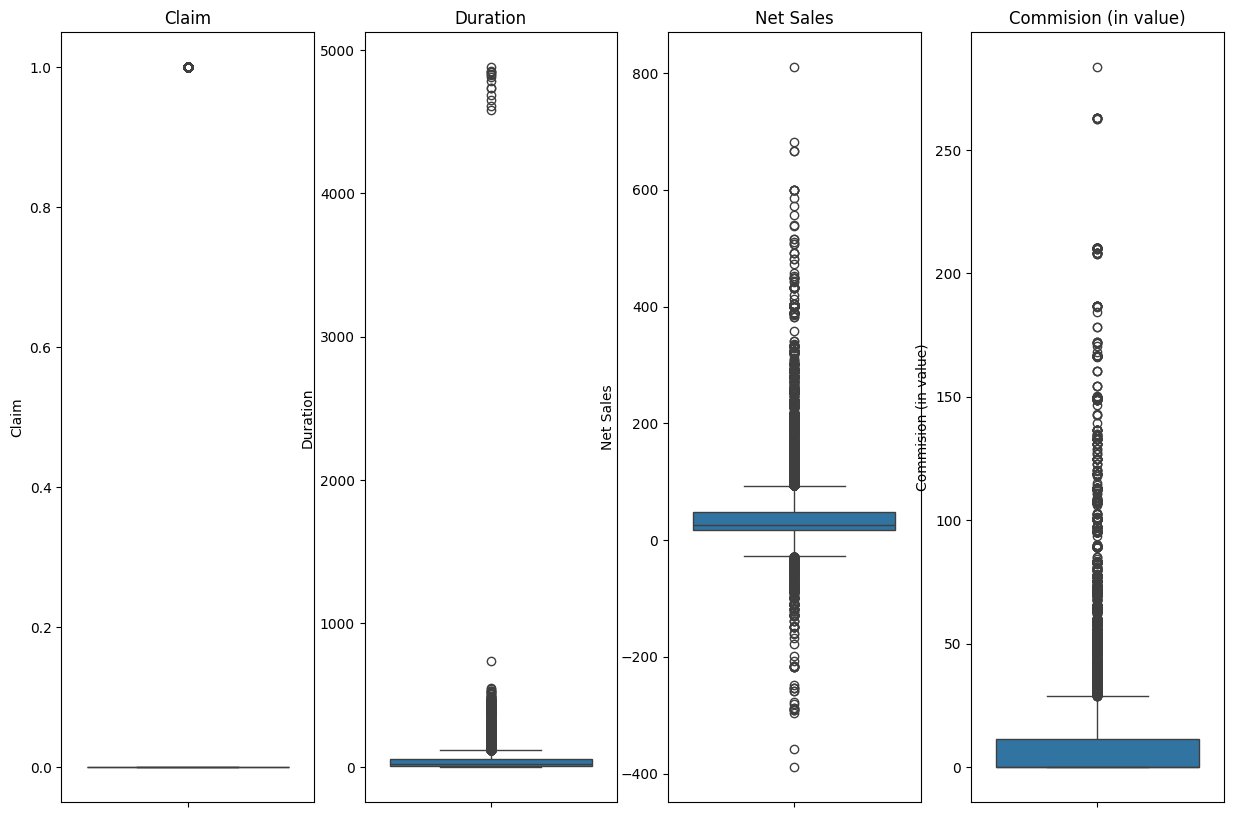

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

number_name=number.columns.to_list()
plt.figure(figsize=(15, 10))
for i in range (4):
  plt.subplot(1, 4, i+1)
  sns.boxplot(y=number[number_name[i]])
  plt.title(number_name[i])

plt.show() #по боксплотам что-то совсем плохо. у всех данных как-то много сомнительных данных но не буду их дропать

In [ ]:
#matrix_corr=pd.DataFrame(final_matrix).corr()
#plt.figure(figsize=(100, 100));
#sns.heatmap(matrix_corr, cmap='coolwarm', annot=True)

'''
ну все таки дропать все категориальные неправильно там есть роляющие признаки

закоментила тк долго отрисовывается
'''

'\nну все таки дропать все категориальные неправильно там есть роляющие признаки\n\nзакоментила тк долго отрисовывается\n'

In [ ]:
def group_countries(country):
    region_mapping = {
    'Asia': [
        'MALAYSIA', 'THAILAND', "KOREA, DEMOCRATIC PEOPLE'S REPUBLIC OF", 'VIET NAM',
        'SINGAPORE', 'JAPAN', 'INDONESIA', 'INDIA', 'CHINA', 'TAIWAN, PROVINCE OF CHINA',
        'PHILIPPINES', 'MYANMAR', 'HONG KONG', 'KOREA, REPUBLIC OF', 'UNITED ARAB EMIRATES',
        'SRI LANKA', 'CAMBODIA', "LAO PEOPLE'S DEMOCRATIC REPUBLIC", 'NEPAL', 'MACAO',
        'BANGLADESH', 'GEORGIA', 'MALDIVES', 'SAUDI ARABIA', 'PAKISTAN', 'QATAR', 'MONGOLIA',
        'CYPRUS', 'FIJI', 'PAPUA NEW GUINEA', 'JORDAN', 'OMAN', 'BAHRAIN', 'AZERBAIJAN',
        'KAZAKHSTAN', 'UZBEKISTAN', 'ARMENIA', 'KYRGYZSTAN', 'LEBANON', 'TURKMENISTAN',
        'BHUTAN', 'IRAN, ISLAMIC REPUBLIC OF', 'TIBET', 'TAJIKISTAN', 'BRUNEI DARUSSALAM'
    ],
    'Europe': [
        'ITALY', 'NORWAY', 'DENMARK', 'UNITED KINGDOM', 'FRANCE', 'POLAND', 'SPAIN',
        'CZECH REPUBLIC', 'GERMANY', 'AUSTRIA', 'NETHERLANDS', 'CROATIA', 'FINLAND',
        'RUSSIAN FEDERATION', 'GREECE', 'BELGIUM', 'IRELAND', 'SWITZERLAND', 'PORTUGAL',
        'ROMANIA', 'ESTONIA', 'LUXEMBOURG', 'SERBIA', 'HUNGARY', 'SLOVENIA', 'BULGARIA',
        'LITHUANIA', 'UKRAINE', 'MOLDOVA, REPUBLIC OF', 'LATVIA', 'MALTA', 'BELARUS',
        'FAROE ISLANDS', 'ALBANIA', 'MACEDONIA, THE FORMER YUGOSLAV REPUBLIC OF',
        'REPUBLIC OF MONTENEGRO', 'BOSNIA AND HERZEGOVINA','ICELAND', 'SWEDEN'
    ],
    'North America': [
        'UNITED STATES', 'CANADA', 'MEXICO', 'COSTA RICA', 'GUAM', 'VIRGIN ISLANDS, U.S.',
        'PANAMA', 'PUERTO RICO', 'CAYMAN ISLANDS', 'BERMUDA', 'DOMINICAN REPUBLIC',
        'TURKS AND CAICOS ISLANDS', 'GREENLAND'
    ],
    'South America': [
        'CHILE', 'ARGENTINA', 'BRAZIL', 'PERU', 'ECUADOR', 'COLOMBIA', 'VENEZUELA',
        'URUGUAY', 'BOLIVIA', 'PARAGUAY', 'GUYANA', 'GUATEMALA'
    ],
    'Africa': [
        'LIBYAN ARAB JAMAHIRIYA','NAMIBIA', 'SOUTH AFRICA', 'TANZANIA, UNITED REPUBLIC OF', 'TUNISIA', 'KENYA',
        'ETHIOPIA', 'BENIN', 'UGANDA', 'MOROCCO', 'GHANA', 'EGYPT', 'SIERRA LEONE',
        'GUINEA', 'ZIMBABWE', 'BOTSWANA', 'MALI', 'SEYCHELLES', 'ZAMBIA', 'NIGERIA',
        'ANGOLA', 'CAMEROON', 'RWANDA', 'SENEGAL','MAURITIUS','GUINEA-BISSAU'
    ],
    'Oceania': [
        'AUSTRALIA', 'NEW ZEALAND', 'NEW CALEDONIA', 'SAMOA', 'SOLOMON ISLANDS',
        'FRENCH POLYNESIA', 'VANUATU','REUNION','NORTHERN MARIANA ISLANDS'
    ],
    'Middle East': [
        'ISRAEL', 'TURKEY', 'LEBANON', 'OMAN', 'BAHRAIN', 'KUWAIT', 'IRAQ', 'YEMEN',
        'SYRIA', 'JORDAN', 'UNITED ARAB EMIRATES', 'SAUDI ARABIA'
    ],
    'Caribbean': [
        'BARBADOS', 'TRINIDAD AND TOBAGO', 'JAMAICA', 'GUADELOUPE', 'HAITI', 'CUBA',
        'BAHAMAS'
    ],
    }#попросила дипсик сгруппировать по регионам ручками я такое бы не сделала ((((

    for region, countries in region_mapping.items():
        if country in countries:
            return region


df['Destination'] = df['Destination'].apply(group_countries)# меняю для каждого элемента в столбце со странами
df = df[df['Duration'] <= 4000].reset_index(drop=True) #выбросы удалим

In [ ]:
from sklearn.utils import resample# как раз использую даунсемплинг

df_majority = df[df['Claim'] == 0]
df_minority = df[df['Claim'] == 1]

df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)#перемешаем

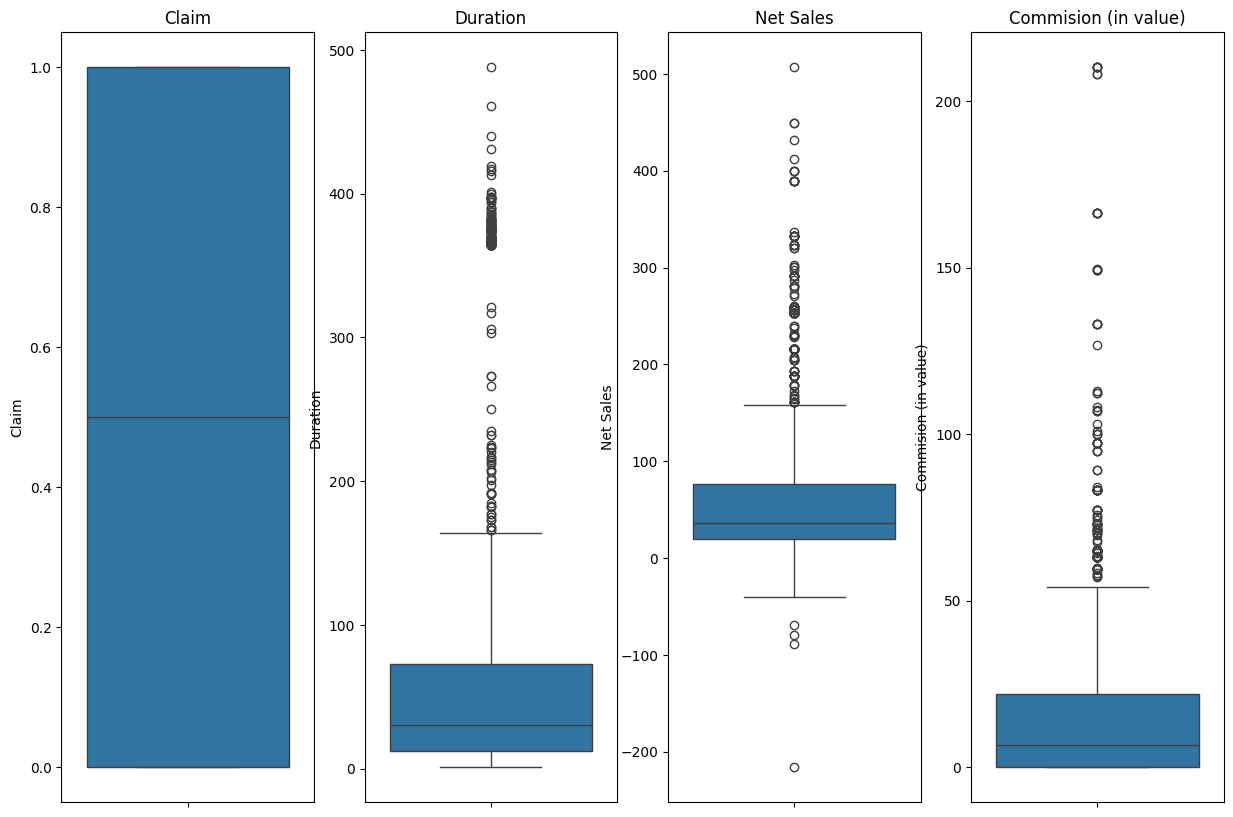

In [ ]:
number_balanced = df_balanced.loc[:, np.logical_not(cat_features_mask)]
import matplotlib.pyplot as plt
import seaborn as sns

number_name=number_balanced.columns.to_list()
plt.figure(figsize=(15, 10))
for i in range (4):
  plt.subplot(1, 4, i+1)
  sns.boxplot(y=number_balanced[number_name[i]])
  plt.title(number_name[i])

plt.show()#снова посмотрю данные на всякий случай

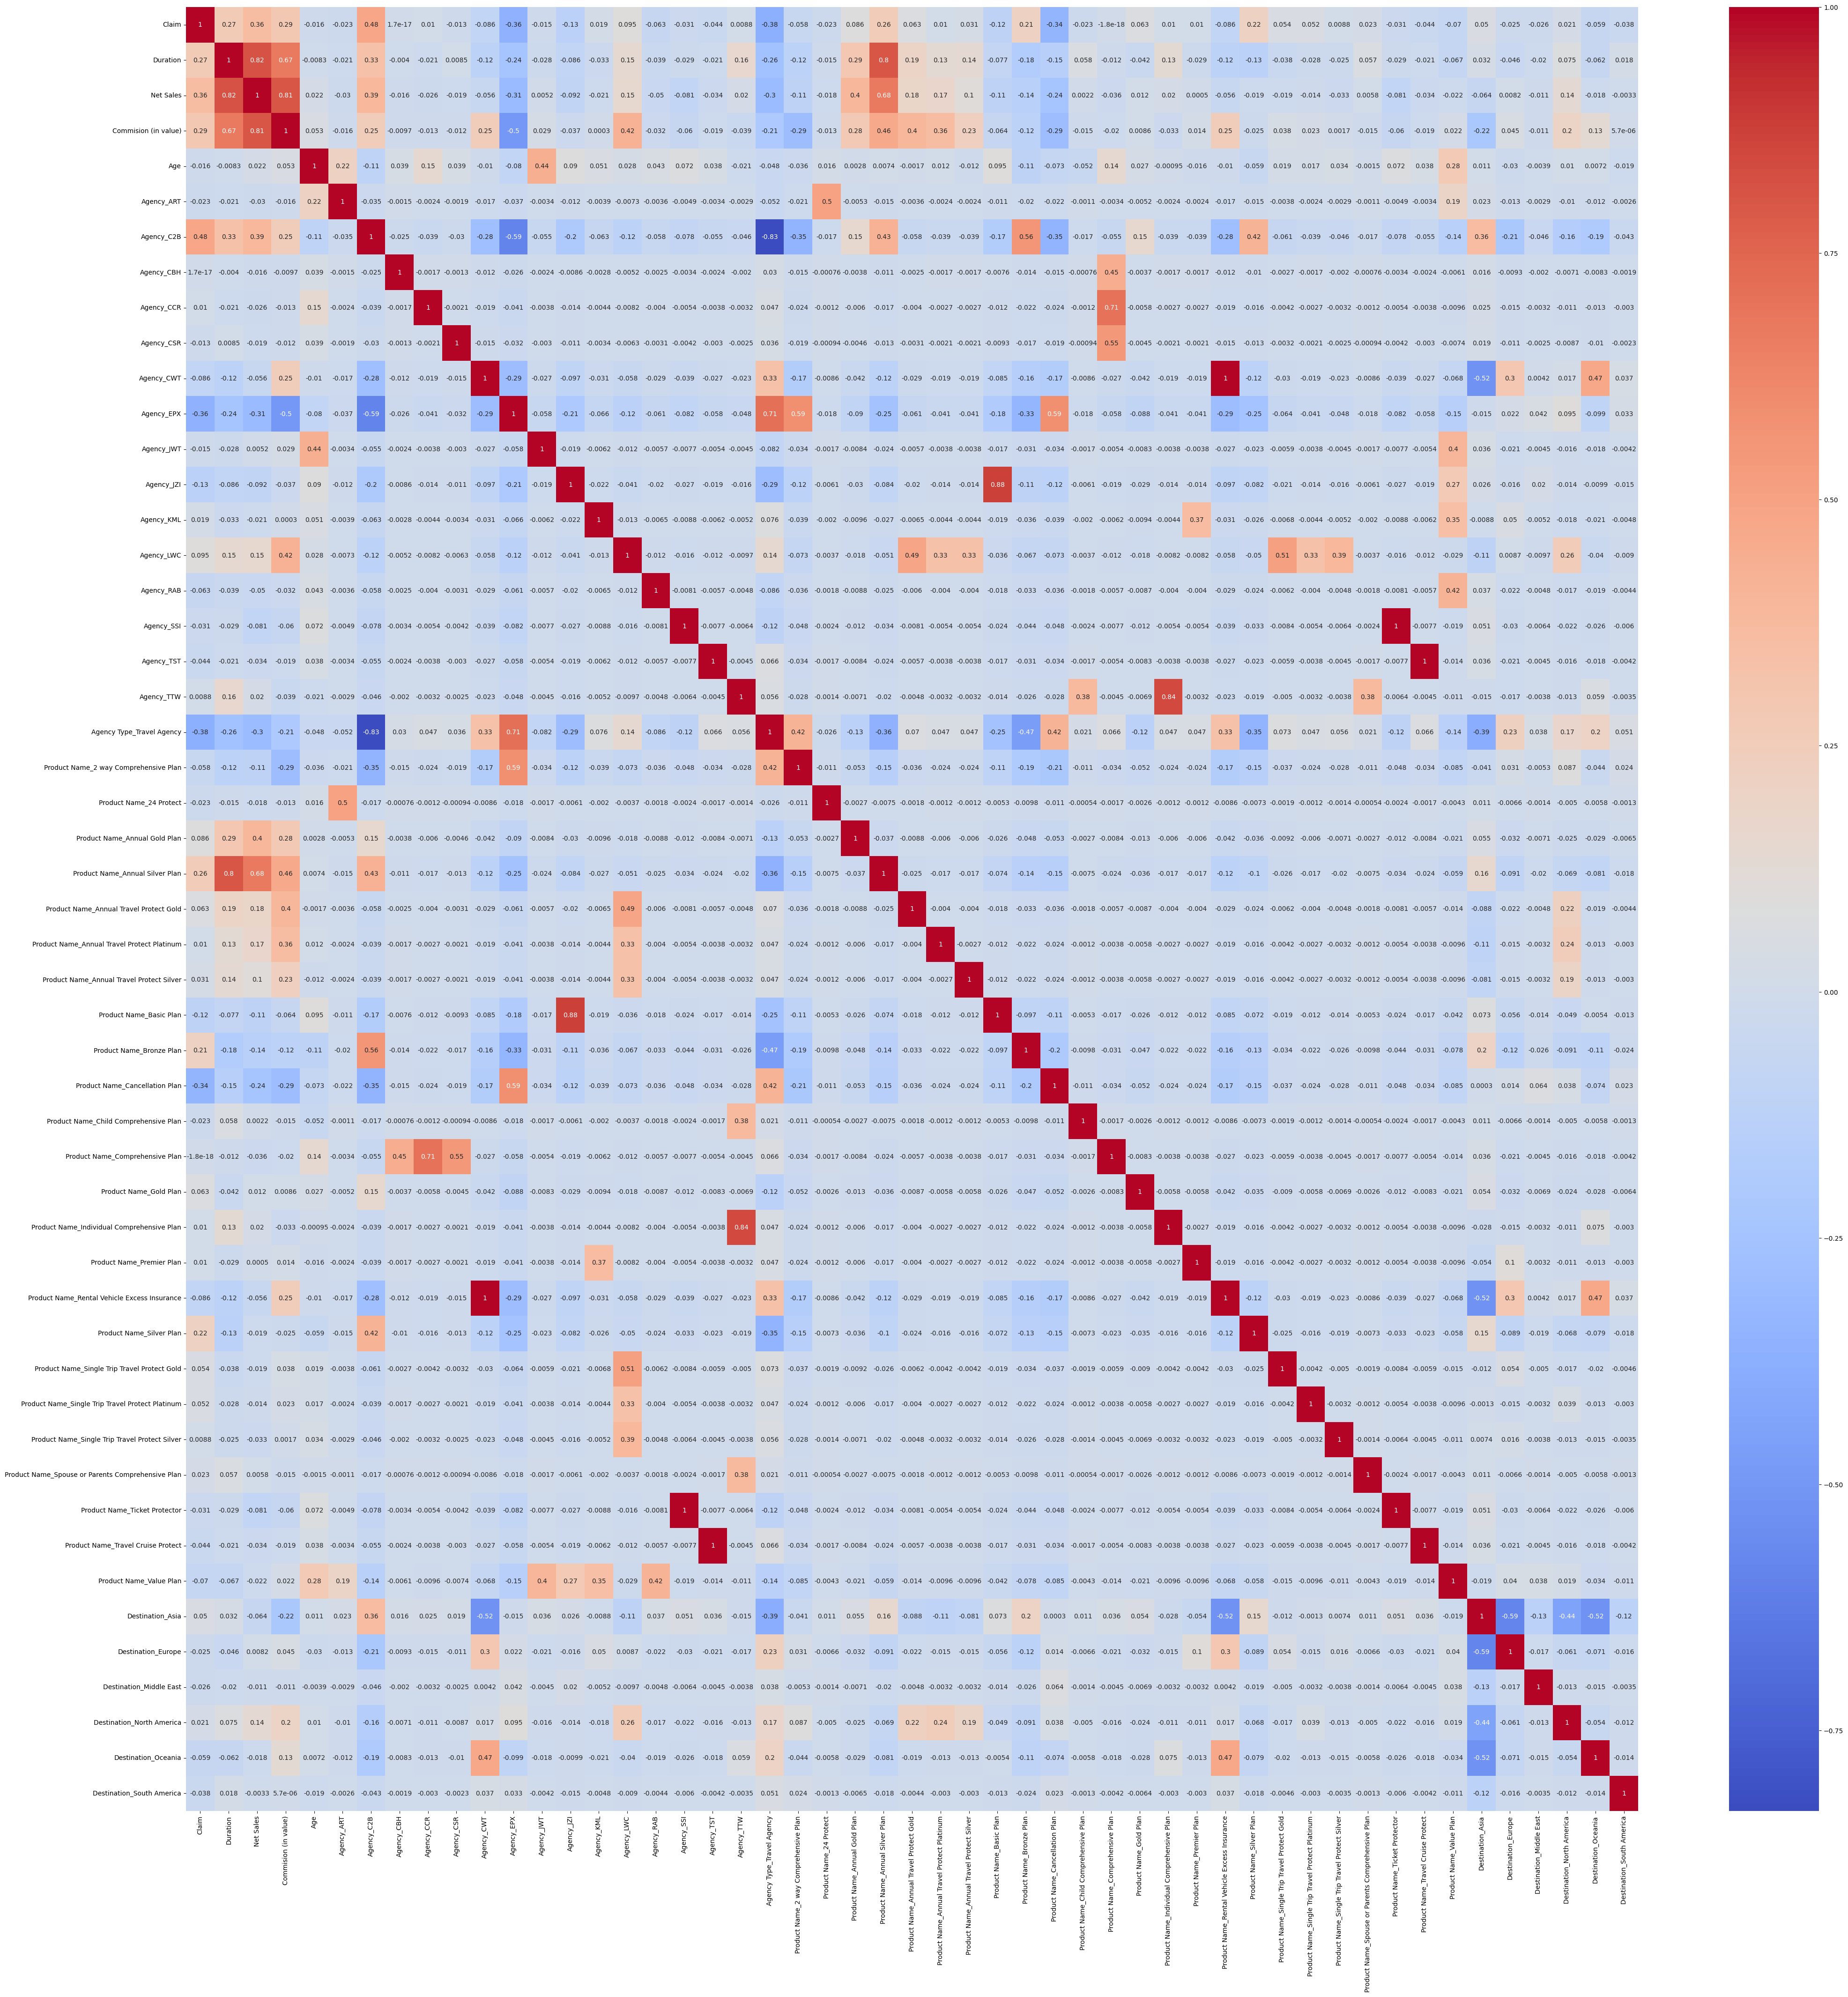

In [ ]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

cat_features = df_balanced.select_dtypes(include=['object']).columns
num_features = df_balanced.select_dtypes(exclude=['object']).columns

encoder = OneHotEncoder(drop='first', sparse_output=False)#во избежание мултиколинеарности
onehot_encoded = encoder.fit_transform(df_balanced[cat_features])
onehot_columns = encoder.get_feature_names_out(cat_features)

scaler = MinMaxScaler()
num_scaled = scaler.fit_transform(df_balanced[num_features])

final_matrix = np.hstack([num_scaled, onehot_encoded])
final_columns = list(num_features) + list(onehot_columns)# чтобы легче анализироват корреляции

final_matrix_with_name = pd.DataFrame(final_matrix, columns=final_columns)

mini_matrix_corr = final_matrix_with_name.corr()
plt.figure(figsize=(50, 50))
sns.heatmap(mini_matrix_corr, cmap='coolwarm', annot=True)
plt.show()


### Применение линейной регрессии (10 баллов)

Это задача классификации, но её можно решить с помощью линейной регрессии, если округлять предсказанный ответ до целого и выбирать ближайший по значению ответ из множества {0, 1}.

Вынесите признак 'Claim' в вектор ответов и разделите датасет на обучающую и тестовую выборку в соотношении 80 к 20. Зафиксируйте random_state.

**Подсказка:** быстро перевести Yes/No в 1/0 можно так - np.where(df['Claim'] == 'Yes', 1,0)

In [ ]:
final_matrix_with_name

,Claim,Duration,Net Sales,Commision (in value),Age,Agency_ART,Agency_C2B,Agency_CBH,Agency_CCR,Agency_CSR,...,Product Name_Spouse or Parents Comprehensive Plan,Product Name_Ticket Protector,Product Name_Travel Cruise Protect,Product Name_Value Plan,Destination_Asia,Destination_Europe,Destination_Middle East,Destination_North America,Destination_Oceania,Destination_South America
0,0.0,0.014374,0.336100,0.032111,0.256881,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.012320,0.334716,0.043290,0.458716,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.778234,0.648479,0.300699,0.229358,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.749487,0.521438,0.191475,0.275229,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.010267,0.326418,0.000000,0.284404,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1.0,0.133470,0.347165,0.000000,0.247706,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1850,1.0,0.751540,0.648479,0.300699,0.348624,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1851,0.0,0.045175,0.329184,0.036630,0.266055,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1852,1.0,0.749487,0.597510,0.256886,0.385321,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# разделение на test/train
y=final_matrix_with_name['Claim']
X=final_matrix_with_name.drop(['Claim'],axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test,y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Найдите аналитическое решение для обучающей выборки: обычное и регуляризацией l2.

In [ ]:
# посчитайте аналитическое решение
X_analytical=X_train.values# тут ужас мучалась а не работает тк это датафрейм но я просто в массив преобразую и все будет круто
y_analytical=y_train.values
coef_analytical=np.linalg.pinv(X_analytical.T @ X_analytical) @ X_analytical.T @ y_analytical
coef_analytical

array([ 5.54663323e-02,  1.10547417e+00,  4.51929322e-02,  5.24362736e-02,
        4.05108345e-01,  4.19543670e-01,  6.94037857e-15,  2.23180385e-01,
        6.10967414e-02,  1.54326217e-01,  1.77496703e-01,  2.76931207e-01,
        3.07763338e-01,  7.78949085e-01,  4.84430488e-01,  1.15306749e-01,
        1.37963159e-01,  1.21145903e-01,  9.63586509e-02, -1.56106207e-01,
        2.35342285e-01,  1.06293056e-15, -2.22582530e-01,  2.53112426e-03,
       -3.10116206e-02, -5.09374562e-01, -1.44418596e-01, -2.54019121e-01,
        2.01433019e-01, -1.94066958e-02, -1.60684520e-01,  2.84277127e-01,
        2.03102431e-01,  2.57043171e-01,  1.10224493e-01,  1.54326217e-01,
        2.35059624e-01,  5.05596573e-01,  4.75811539e-01,  1.87827154e-01,
        0.00000000e+00,  1.37963159e-01,  1.21145903e-01, -2.25237028e-01,
       -2.64893758e-01, -1.45155443e-01, -2.17292066e-01, -1.47926496e-01,
       -2.05920511e-01, -2.41462117e-01])

In [ ]:
# посчитать аналитическое решение с регуляризацией
X_analytical_l2=X_train.values
y_analytical_l2=y_train.values
lambda_analytical=1
coef_analytical_l2=np.linalg.pinv(X_analytical_l2.T @ X_analytical_l2 + lambda_analytical*np.eye(X_analytical_l2.shape[1])) @ X_analytical_l2.T @ y_analytical_l2
coef_analytical_l2

array([ 3.70184569e-02,  8.54065385e-01,  9.88636552e-02,  8.57916003e-02,
        1.23858695e-01,  3.97402441e-01,  3.16553074e-14,  1.08340622e-01,
       -9.91448899e-03,  2.53579737e-02, -7.44906116e-02,  4.37027793e-02,
        9.59446308e-02,  3.69726120e-01,  2.77469448e-01, -9.25239423e-02,
        9.72294918e-02, -8.62785327e-03, -1.60274135e-02,  3.57282294e-02,
        2.36345393e-01, -8.79367105e-14, -1.51843280e-01,  2.76650023e-02,
       -3.27056011e-02, -4.19156086e-01, -1.23058336e-01, -1.09692408e-01,
        1.60080001e-01, -2.41182747e-02, -1.33645994e-01,  9.84261335e-02,
        1.63004101e-01,  1.17618580e-01,  9.43233969e-02,  2.53579737e-02,
        1.98496617e-01,  4.06511606e-01,  3.36177000e-01,  1.09700866e-01,
        3.29179859e-14,  9.72294918e-02, -8.62785327e-03, -8.00282743e-02,
       -1.22952886e-01,  4.88481418e-03, -6.13783132e-02, -9.42443678e-04,
       -6.04293113e-02, -7.99658739e-02])

Постройте модель LinearRegression, примените к тестовой выборке и посчитайте MSE (можно использовать библиотеку sklearn)

In [ ]:
# обучите модель линейной регрессии LinearRegression на обучающей выборке, примените к тестовой
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
# посчитайте MSE, предварительно округлив предсказанные ответы до целого
import numpy as np
from sklearn.metrics import f1_score, mean_squared_error

y_train_prob = lin_reg.predict(X_train)
y_test_prob = lin_reg.predict(X_test)

best_f1_train = 0
best_f1_test = 0
best_threshold = 0

for threshold in np.arange(0.0, 1, 0.01):#хочу подобрать порог когда я буду приравнивать к 1 а то у меня все предсказания 0 тк дисбаланс класса

    y_train_pred = (y_train_prob >= threshold).astype(int)
    y_test_pred = (y_test_prob >= threshold).astype(int)

    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)

    if f1_train > best_f1_train:
        best_f1_train = f1_train
        best_f1_test = f1_test
        best_threshold = threshold

print(f"Лучший порог: {best_threshold}")
print(f"F1-метрика на обучающей выборке: {best_f1_train}")
print(f"F1-метрика на тестовой выборке: {best_f1_test}")

y_train_pred = (lin_reg.predict(X_train) >= best_threshold).astype(int)
y_test_pred = (lin_reg.predict(X_test) >= best_threshold).astype(int)

print(mean_squared_error(y_train, y_train_pred), 'Train')
print(mean_squared_error(y_test, y_test_pred), 'Test')

Лучший порог: 0.37
F1-метрика на обучающей выборке: 0.776084407971864
F1-метрика на тестовой выборке: 0.713216957605985
0.25758597437626435 Train
0.30997304582210244 Test


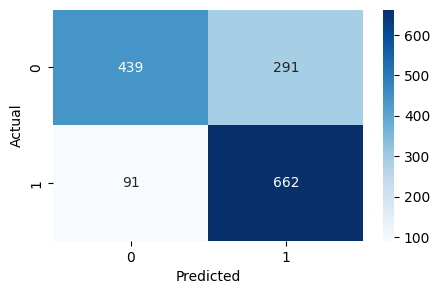

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show() # ну я честно не знаю выходит неочень.....

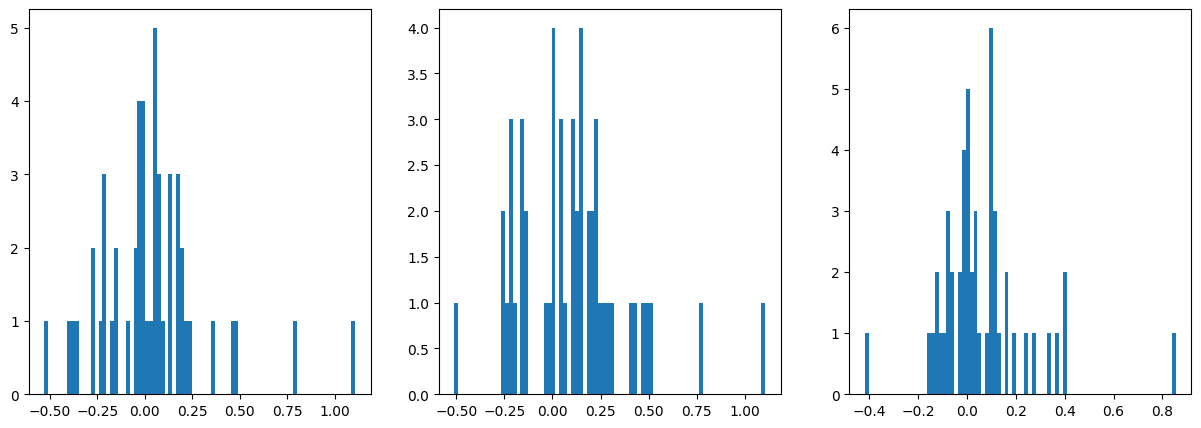

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(lin_reg.coef_, bins=80)

plt.subplot(1, 3, 2)
plt.hist(coef_analytical, bins=80)

plt.subplot(1, 3, 3)
plt.hist(coef_analytical_l2, bins=80)
plt.show()

### Вывод (1 балла)

Напишите краткий вывод по заданию (достаточно пары предложений). Расскажите, какие способы предобработки данных вы выбрали и почему. Насколько хороша ваша модель?

In [ ]:
'''
я делала пометки в коде, но просуммирую
изначально в данных дисбаланс по предсказываемой категории
я посчитала нужным попробовать ухватить категориальные фичи поэтому сгруппировала страны по частям света
по итогу не могу сказать что это дало преимущество в результате

также я удалила выбросы на которые акцентировали внимание.
Почитала и применила Downsampling, датасет достаточно большой можно было пожертвовать объемом

очень много сложностей с пониманием какие признаки можно дропать...ну наверное с опытом придет.
(можно было дропать одну из бинарных колонок(offline online) с заменой на 0 и 1 что-то в начале об этом не подумала а потом как-то уже не хотелось)
в начале кажется что все признаки очень нужны но потом в решении плюса что-то не заметила

я уменьшить порог для выдавания 1, а точно бы все было по 0

мсе на тесте и трейне примерно равны но в нашей задаче это ничего не значит
(как будто выводить 0 всегда было бы выйгрышней если бы не сбалансили классы)

Ниже еще два решения но отличие только в том какие данные берем.
но там тоже как-то грустно по метрикам. страны в итоге вообще не влияли, зря столько мучений.
а вот наличие категориальных дало плюсом небольшое повышение точности но все равно приятно
плюс в другом ноутбуке я попробовала удалить "выбросы" и по другим численным категориям по iqr но там тоже в итоге ничего лучшего по качестутву не вышло

вообщем стоит отметить что мы хорошо попападаем в людей которым нужна страховка, но будет много ложных обзвонов,
когда модель выдала 1 а на самом деле им страховка не нужна.
но в нашей постановке это будет лучше, чем повысиить порог и пропустит кому она на самом деле нужна,
тк задача ориентирована именно на выявление 1

'''

'\nя делала пометки в коде, но просуммирую\nизначально в данных дисбаланс по предсказываемой категории\nя посчитала нужным попробовать ухватить категориальные фичи поэтому сгруппировала страны по частям света\nпо итогу не могу сказать что это дало преимущество в результате\n\nтакже я удалила выбросы на которые акцентировали внимание.\nПочитала и применила Downsampling, датасет достаточно большой можно было пожертвовать объемом\n\nочень много сложностей с пониманием какие признаки можно дропать...ну наверное с опытом придет.\n(можно было дропать одну из бинарных колонок(offline online) с заменой на 0 и 1 что-то в начале об этом не подумала а потом как-то уже не хотелось)\nв начале кажется что все признаки очень нужны но потом в решении плюса что-то не заметила\n\nя уменьшить порог для выдавания 1, а точно бы все было по 0\n\nмсе на тесте и трейне примерно равны но в нашей задаче это ничего не значит\n(как будто выводить 0 всегда было бы выйгрышней если бы не сбалансили классы)\n\nНиже е

# Попробовала без категориальных

In [ ]:
import pandas as pd
import numpy as np

url='https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv'
df=pd.read_csv(url)
df=df.drop(['Gender'],axis=1)
df['Claim']=np.where(df['Claim'] == 'Yes', 1,0)
cat_features_mask = (df.dtypes == "object").values
cat_columns = df.columns[cat_features_mask]
df = df.drop(cat_columns, axis=1)
df = df[df['Duration'] <= 4000].reset_index(drop=True)
df

,Claim,Duration,Net Sales,Commision (in value),Age
0,0,186,-29.0,9.57,81
1,0,186,-29.0,9.57,71
2,0,65,-49.5,29.70,32
3,0,60,-39.6,23.76,32
4,0,79,-19.8,11.88,41
...,...,...,...,...,...
63307,0,111,35.0,12.25,31
63308,0,58,40.0,14.00,40
63309,0,2,18.0,6.30,57
63310,0,3,18.0,6.30,63


In [ ]:
from sklearn.utils import resample# как раз использую даунсемплинг

df_majority = df[df['Claim'] == 0]
df_minority = df[df['Claim'] == 1]

df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_balanced), columns=df_balanced.columns)
df_scaled

,Claim,Duration,Net Sales,Commision (in value),Age
0,0.0,0.014374,0.336100,0.032111,0.256881
1,0.0,0.012320,0.334716,0.043290,0.458716
2,1.0,0.778234,0.648479,0.300699,0.229358
3,1.0,0.749487,0.521438,0.191475,0.275229
4,0.0,0.010267,0.326418,0.000000,0.284404
...,...,...,...,...,...
1849,1.0,0.133470,0.347165,0.000000,0.247706
1850,1.0,0.751540,0.648479,0.300699,0.348624
1851,0.0,0.045175,0.329184,0.036630,0.266055
1852,1.0,0.749487,0.597510,0.256886,0.385321


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
y=df_scaled['Claim']
X=df_scaled.drop(['Claim'],axis=1)
X_train, X_test,y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


LinearRegression()

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, mean_squared_error

y_train_prob = lin_reg.predict(X_train)
y_test_prob = lin_reg.predict(X_test)

best_f1_train = 0
best_f1_test = 0
best_threshold = 0

for threshold in np.arange(0.0, 1, 0.01):#хочу подобрать порог когда я буду приравнивать к 1 а то у меня все предсказания 0 тк дисбаланс класса

    y_train_pred = (y_train_prob >= threshold).astype(int)
    y_test_pred = (y_test_prob >= threshold).astype(int)

    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)

    if f1_train > best_f1_train:
        best_f1_train = f1_train
        best_f1_test = f1_test
        best_threshold = threshold

print(f"Лучший порог: {best_threshold}")
print(f"F1-метрика на обучающей выборке: {best_f1_train}")
print(f"F1-метрика на тестовой выборке: {best_f1_test}")

y_train_pred = (lin_reg.predict(X_train) >= best_threshold).astype(int)
y_test_pred = (lin_reg.predict(X_test) >= best_threshold).astype(int)

print(mean_squared_error(y_train, y_train_pred), 'Train')
print(mean_squared_error(y_test, y_test_pred), 'Test')

Лучший порог: 0.41000000000000003
F1-метрика на обучающей выборке: 0.703601108033241
F1-метрика на тестовой выборке: 0.691415313225058
0.3607552258934592 Train
0.3584905660377358 Test


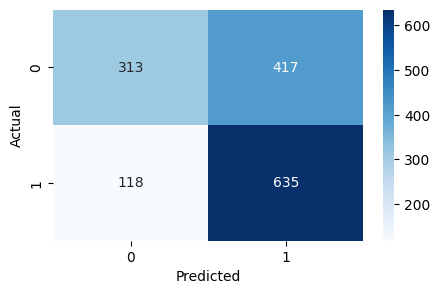

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Попробовала без стран

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

url='https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv'
df=pd.read_csv(url)
df=df.drop(['Gender','Destination'],axis=1)
df = df[df['Duration'] <= 4000].reset_index(drop=True)
df['Claim']=np.where(df['Claim'] == 'Yes', 1,0)

from sklearn.utils import resample

df_majority = df[df['Claim'] == 0]
df_minority = df[df['Claim'] == 1]

df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


cat_features = df_balanced.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(sparse_output=False, drop='first')
onehot_encoded = encoder.fit_transform(df_balanced[cat_features])

onehot_column_names = encoder.get_feature_names_out(cat_features)
df_onehot = pd.DataFrame(onehot_encoded, columns=onehot_column_names)

df_final = pd.concat([df_balanced.drop(columns=cat_features), df_onehot], axis=1)

df_final

,Claim,Duration,Net Sales,Commision (in value),Age,Agency_ART,Agency_C2B,Agency_CBH,Agency_CCR,Agency_CSR,...,Product Name_Premier Plan,Product Name_Rental Vehicle Excess Insurance,Product Name_Silver Plan,Product Name_Single Trip Travel Protect Gold,Product Name_Single Trip Travel Protect Platinum,Product Name_Single Trip Travel Protect Silver,Product Name_Spouse or Parents Comprehensive Plan,Product Name_Ticket Protector,Product Name_Travel Cruise Protect,Product Name_Value Plan
0,0,8,27.00,6.75,37,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,7,26.00,9.10,59,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1,380,252.85,63.21,34,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,366,161.00,40.25,39,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,6,20.00,0.00,40,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1,66,35.00,0.00,36,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1850,1,367,252.85,63.21,47,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1851,0,23,22.00,7.70,38,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1852,1,366,216.00,54.00,51,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_final), columns=df_final.columns)
df_scaled

,Claim,Duration,Net Sales,Commision (in value),Age,Agency_ART,Agency_C2B,Agency_CBH,Agency_CCR,Agency_CSR,...,Product Name_Premier Plan,Product Name_Rental Vehicle Excess Insurance,Product Name_Silver Plan,Product Name_Single Trip Travel Protect Gold,Product Name_Single Trip Travel Protect Platinum,Product Name_Single Trip Travel Protect Silver,Product Name_Spouse or Parents Comprehensive Plan,Product Name_Ticket Protector,Product Name_Travel Cruise Protect,Product Name_Value Plan
0,0.0,0.014374,0.336100,0.032111,0.256881,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.012320,0.334716,0.043290,0.458716,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.778234,0.648479,0.300699,0.229358,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.749487,0.521438,0.191475,0.275229,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.010267,0.326418,0.000000,0.284404,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,1.0,0.133470,0.347165,0.000000,0.247706,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1850,1.0,0.751540,0.648479,0.300699,0.348624,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1851,0.0,0.045175,0.329184,0.036630,0.266055,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1852,1.0,0.749487,0.597510,0.256886,0.385321,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


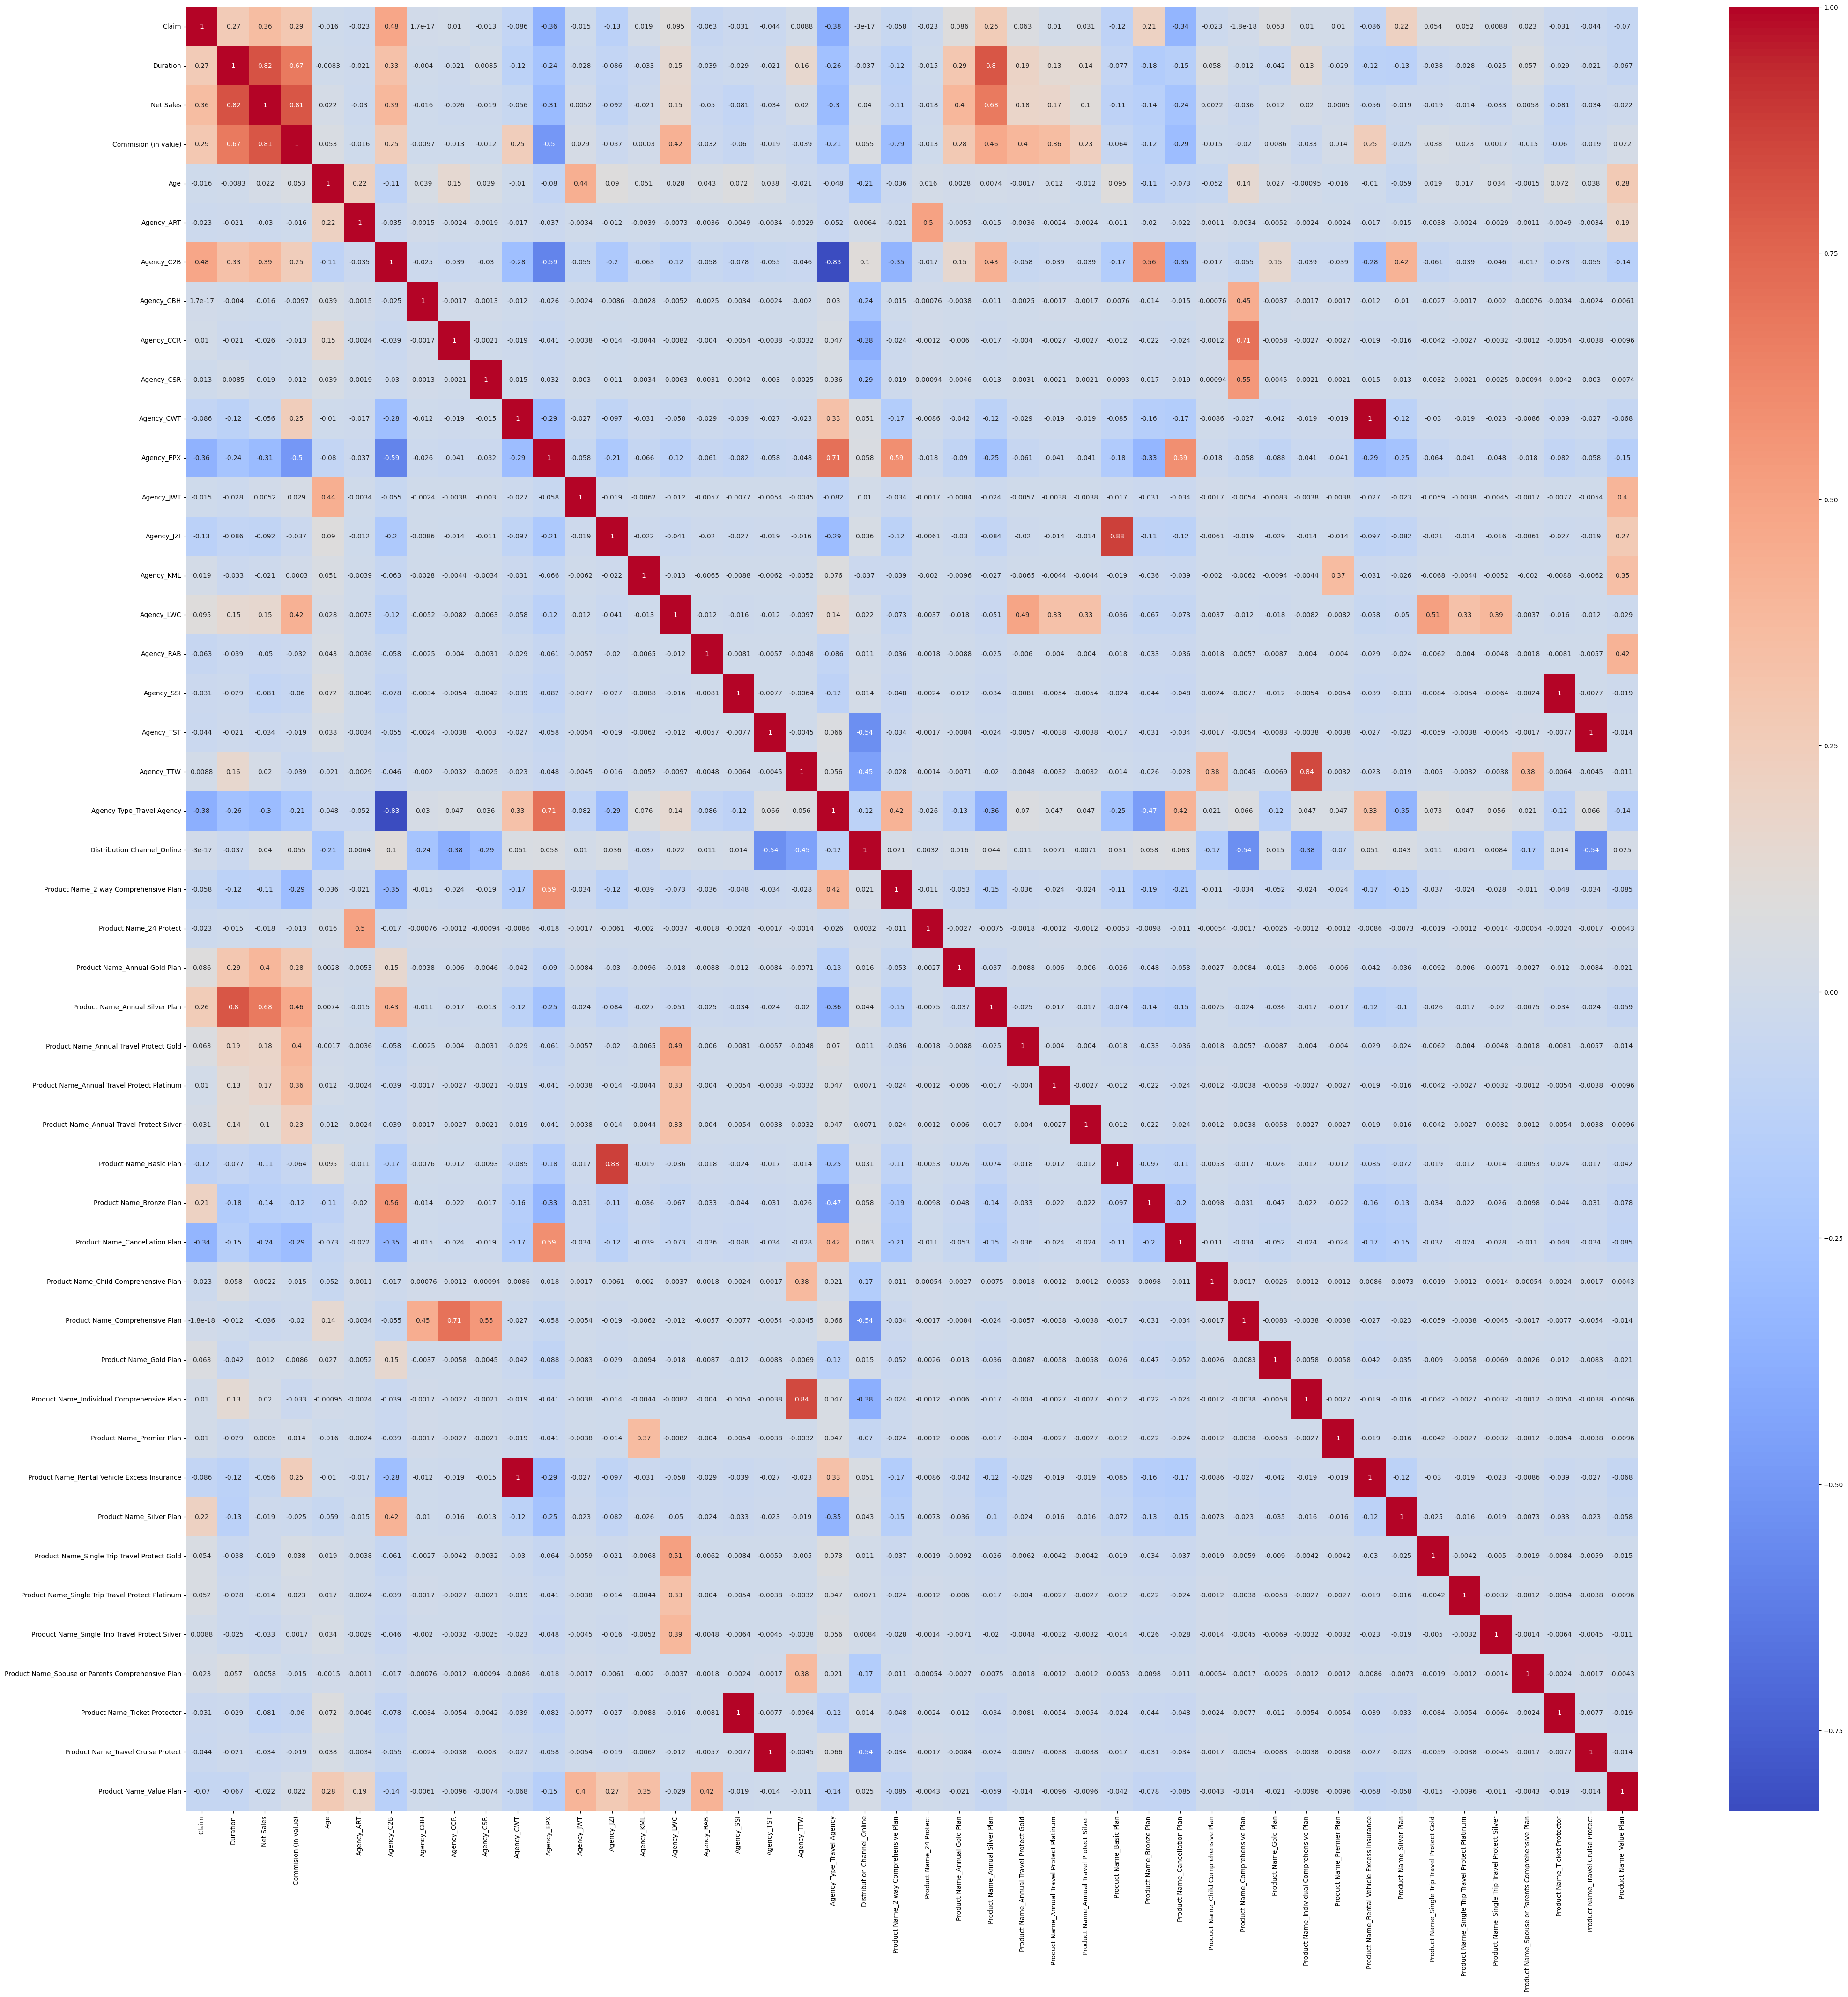

In [ ]:
plt.figure(figsize=(50, 50))
sns.heatmap(df_scaled.corr(), cmap='coolwarm', annot=True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
y=df_scaled['Claim']
X=df_scaled.drop(['Claim'],axis=1)
X_train, X_test,y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


LinearRegression()

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, mean_squared_error

y_train_prob = lin_reg.predict(X_train)
y_test_prob = lin_reg.predict(X_test)

best_f1_train = 0
best_f1_test = 0
best_threshold = 0

for threshold in np.arange(0.0, 1, 0.01):#хочу подобрать порог когда я буду приравнивать к 1 а то у меня все предсказания 0 тк дисбаланс класса

    y_train_pred = (y_train_prob >= threshold).astype(int)
    y_test_pred = (y_test_prob >= threshold).astype(int)

    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)

    if f1_train > best_f1_train:
        best_f1_train = f1_train
        best_f1_test = f1_test
        best_threshold = threshold

print(f"Лучший порог: {best_threshold}")
print(f"F1-метрика на обучающей выборке: {best_f1_train}")
print(f"F1-метрика на тестовой выборке: {best_f1_test}")

y_train_pred = (lin_reg.predict(X_train) >= best_threshold).astype(int)
y_test_pred = (lin_reg.predict(X_test) >= best_threshold).astype(int)

print(mean_squared_error(y_train, y_train_pred), 'Train')
print(mean_squared_error(y_test, y_test_pred), 'Test')

Лучший порог: 0.38
F1-метрика на обучающей выборке: 0.7845968712394705
F1-метрика на тестовой выборке: 0.7175572519083969
0.24140256237356708 Train
0.2991913746630728 Test


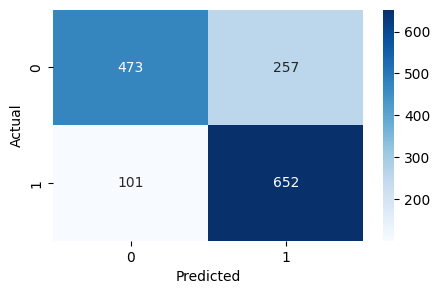

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()